In [1]:
import pandas as pd

# Загружаем данные
file_path = "5_task_1.csv"
df = pd.read_csv(file_path)

# Выведем общую информацию о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      30000 non-null  int64 
 1   group   30000 non-null  object
 2   events  30000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 703.2+ KB


In [8]:
from scipy import stats

In [11]:
group_A = df.loc[df['group'] == 'A', 'events']
group_B = df.loc[df['group'] == 'B', 'events']
group_C = df.loc[df['group'] == 'C', 'events']

In [12]:
 scipy.stats.levene(group_A, group_B, group_C)

LeveneResult(statistic=2.2622596339318037, pvalue=0.1041327199523974)

In [13]:
scipy.stats.normaltest(group_A)

NormaltestResult(statistic=2.1034599402238734, pvalue=0.3493328906085719)

In [14]:
scipy.stats.normaltest(group_B)

NormaltestResult(statistic=0.8410715800223014, pvalue=0.6566948749848232)

In [15]:
scipy.stats.normaltest(group_C)

NormaltestResult(statistic=3.243725809054571, pvalue=0.19753037588314626)

In [16]:
scipy.stats.f_oneway(group_A, group_B, group_C)

F_onewayResult(statistic=2886.166657438961, pvalue=0.0)

In [21]:
from statsmodels import stats 

In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [27]:
statsmodels.stats.multicomp.pairwise_tukeyhsd(df['events'], df['group']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
A,B,8.034,0.001,7.7038,8.3642,True
A,C,-2.1093,0.001,-2.4395,-1.7791,True
B,C,-10.1433,0.001,-10.4735,-9.8131,True


In [28]:
# Загружаем данные
file_path_2 = "5_task_2.csv"
df_2 = pd.read_csv(file_path_2)

# Выведем общую информацию о данных
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  int64  
 1   group    100000 non-null  object 
 2   segment  100000 non-null  object 
 3   events   100000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.1+ MB


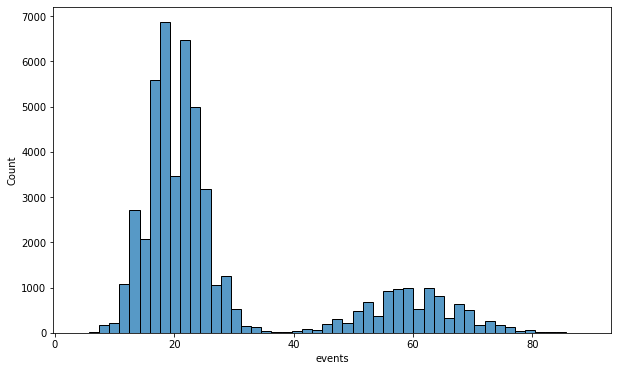

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Разделяем данные на контрольную и тестовую группы
control_group = df_2[df_2['group'] == 'control']
test_group = df_2[df_2['group'] == 'test']

# Создаем график
plt.figure(figsize=(10, 6))

# Строим гистог-2рамму для контрольной группы
sns.histplot(control_group['events'], bins=50)


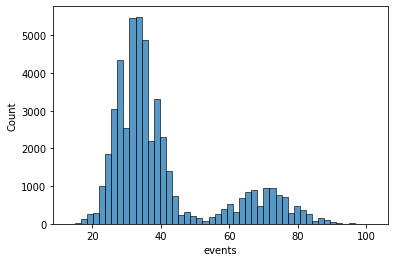

In [42]:
sns.histplot(test_group['events'], bins=50)

In [43]:
control_group.groupby('segment').describe()

id                                                               \
           count        mean           std   min       25%      50%       75%   
segment                                                                         
high     10000.0  50473.9782  28761.438914  10.0  25612.50  51031.0  75261.25   
low      40000.0  49935.2567  28855.849243   0.0  25022.25  49944.5  74874.25   

                   events                                                     
             max    count       mean       std   min   25%   50%   75%   max  
segment                                                                       
high     99976.0  10000.0  59.970800  7.805347  31.0  55.0  60.0  65.0  89.0  
low      99999.0  40000.0  20.031575  4.473576   4.0  17.0  20.0  23.0  41.0

In [44]:
test_group.groupby('segment').describe()

id                                                               \
           count        mean           std   min       25%      50%       75%   
segment                                                                         
high     10000.0  50126.6206  28821.133487  14.0  25317.50  50234.5  74783.25   
low      40000.0  49913.3436  28917.383492   1.0  24763.75  49706.5  75127.25   

                   events                                                      
             max    count       mean       std   min   25%   50%   75%    max  
segment                                                                        
high     99996.0  10000.0  69.938500  8.403974  40.0  64.0  70.0  76.0  102.0  
low      99995.0  40000.0  33.025925  5.720845  13.0  29.0  33.0  37.0   59.0

In [47]:
import statsmodels.formula.api as smf

In [49]:
a = smf.ols('events ~ segment + group + segment:group', df_2).fit()

In [50]:
a

In [52]:
from statsmodels.stats.anova import anova_lm

In [53]:
anova_lm(a, typ = 2)

,sum_sq,df,F,PR(>F)
segment,2.362480e+07,1.0,689756.377484,0.000000e+00
group,3.837195e+06,1.0,112031.864119,0.000000e+00
segment:group,3.664244e+04,1.0,1069.823273,2.060261e-233
Residual,3.424956e+06,99996.0,NaN,NaN


In [55]:
df_2['combination'] = df_2['segment'] + ' \ ' + df_2['group']

In [57]:
statsmodels.stats.multicomp.pairwise_tukeyhsd(df_2['events'], df_2['segment']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
high,low,-38.4259,0.001,-38.5583,-38.2935,True


In [58]:
statsmodels.stats.multicomp.pairwise_tukeyhsd(df_2['events'], df_2['group']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
control,test,12.389,0.001,12.185,12.593,True


In [59]:
statsmodels.stats.multicomp.pairwise_tukeyhsd(df_2['events'], df_2['combination']).summary()

group1,group2,meandiff,p-adj,lower,upper,reject
high \ control,high \ test,9.9677,0.001,9.7551,10.1803,True
high \ control,low \ control,-39.9392,0.001,-40.1073,-39.7711,True
high \ control,low \ test,-26.9449,0.001,-27.113,-26.7768,True
high \ test,low \ control,-49.9069,0.001,-50.075,-49.7388,True
high \ test,low \ test,-36.9126,0.001,-37.0807,-36.7445,True
low \ control,low \ test,12.9944,0.001,12.888,13.1007,True
